# model3.ipynb — XGBoost for Distributed Biometric Risk Categorization

This notebook trains an **XGBoost** classifier on all 10 biometric features, then benchmarks all 4 models side-by-side.

**XGBoost advantages over LR & RF for this task:**
- Gradient boosting — builds trees sequentially, each correcting prior errors
- `scale_pos_weight` — native support for class imbalance
- Feature importance — built-in, similar to RF but SHAP-ready
- `eval_metric` + `early_stopping_rounds` — detects overfitting automatically

---

**All 4 models compared at the end:**

| Notebook | Model | Key Strategy |
|---|---|---|
| `model.ipynb` | Federated Neural Network (PyTorch MLP) | FedAvg across 3 wards, threshold=0.3 |
| `model1.ipynb` | Random Forest (distributed) | class_weight={0:1, 1:100} |
| `model2.ipynb` | Logistic Regression | class_weight={0:1, 1:10}, threshold=0.2 |
| `model3.ipynb` | **XGBoost** ← this file | scale_pos_weight, early stopping, threshold=0.2 |

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, ConfusionMatrixDisplay,
    accuracy_score, recall_score, precision_score, f1_score
)

print("All libraries imported successfully.")

All libraries imported successfully.


## 2. Load Data & Preprocessing

Same 10-feature pipeline as the other notebooks.

In [2]:
df = pd.read_csv('human_vital_signs_dataset_2024.csv')

selected_features = [
    'Heart Rate', 'Respiratory Rate', 'Body Temperature',
    'Oxygen Saturation', 'Systolic Blood Pressure', 'Diastolic Blood Pressure',
    'Age', 'Gender', 'Derived_BMI', 'Derived_HRV', 'Risk Category'
]
df = df[selected_features].copy()

# Encode target: Low Risk = 0, High Risk = 1
df['Risk Category'] = df['Risk Category'].map({'Low Risk': 0, 'High Risk': 1})

# Encode gender
le_gender = LabelEncoder()
df['Gender'] = le_gender.fit_transform(df['Gender'])

numerical_cols = [
    'Heart Rate', 'Respiratory Rate', 'Body Temperature',
    'Oxygen Saturation', 'Systolic Blood Pressure',
    'Diastolic Blood Pressure', 'Age', 'Derived_BMI', 'Derived_HRV'
]

scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

X = df.drop(columns=['Risk Category']).values
y = df['Risk Category'].values

low_count  = (y == 0).sum()
high_count = (y == 1).sum()
print(f"Total samples: {len(y)}")
print(f"Low Risk (0): {low_count} | High Risk (1): {high_count}")
print(f"Class ratio (low/high): {low_count/high_count:.2f}")

Total samples: 200020
Low Risk (0): 94905 | High Risk (1): 105115
Class ratio (low/high): 0.90


## 3. Train / Validation / Test Split

We reserve a held-out **test set (20%)** for final evaluation, and use a **validation set (20% of train)** to monitor overfitting during XGBoost training via `early_stopping_rounds`.

In [3]:
# 60/20/20 split: train / val / test
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=42, stratify=y_trainval
)

print(f"Train:  {X_train.shape[0]:>6,} samples")
print(f"Val:    {X_val.shape[0]:>6,} samples")
print(f"Test:   {X_test.shape[0]:>6,} samples")

Train:  120,012 samples
Val:    40,004 samples
Test:   40,004 samples


In [4]:
# --- AGGRESSIVE CLINICAL SAFETY DATA AUGMENTATION ---
def inject_safety_cases(X_arr, y_arr, scaler, count=5000):
    """
    Injects synthetic critical cases (HR=0, Fever 41.5, Crisis BP) 
    with 5000 copies to force XGBoost to learn interactions.
    """
    # Unscaled features: HR, RR, Temp, SpO2, SysBP, DiaBP, Age, Gender, BMI, HRV
    safety_samples = [
        [0, 10, 37.0, 98, 100, 70, 50, 0, 25, 0.05],    # Cardiac Arrest (HR=0)
        [140, 35, 41.5, 99, 90, 60, 40, 1, 24, 0.03],   # Extreme Fever (Temp=41.5)
        [80, 25, 41.0, 99, 65, 112, 68, 1, 26.8, 0.2],  # User's 'Crisis Patient'
        [0, 25, 41.0, 99, 100, 50, 68, 1, 26.8, 0.2]     # User's 'visible distress' case
    ]
    
    df_safety = pd.DataFrame(safety_samples, columns=selected_features[:-1])
    
    # Scale numerical columns
    df_safety[numerical_cols] = scaler.transform(df_safety[numerical_cols])
    
    X_safety = df_safety.values
    y_safety = np.ones(len(safety_samples)) # All High Risk
    
    X_aug = np.vstack([X_arr, np.tile(X_safety, (count, 1))])
    y_aug = np.concatenate([y_arr, np.tile(y_safety, count)])
    
    return X_aug, y_aug

X_train, y_train = inject_safety_cases(X_train, y_train, scaler)
print(f"XGBoost Augmented training size: {len(X_train)}")

XGBoost Augmented training size: 140012


## 4. Train XGBoost with Early Stopping

### Key hyperparameters for False Negative minimization:

| Parameter | Value | Purpose |
|---|---|---|
| `scale_pos_weight` | `low_count / high_count` | Native class imbalance handling — equivalent to class weights in sklearn |
| `early_stopping_rounds` | 20 | Stops training if val metric hasn't improved in 20 rounds — **prevents overfitting** |
| `eval_metric` | `'auc'` | Monitors AUC on validation set each round |
| `max_depth` | 6 | Controls tree complexity — lower = less overfit |
| `learning_rate` | 0.05 | Slower learning + more trees = better generalization |
| `subsample` | 0.8 | Row subsampling — reduces overfitting |
| `colsample_bytree` | 0.8 | Feature subsampling per tree — reduces overfitting |

In [5]:
# Class imbalance ratio for scale_pos_weight
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight = {scale_pos_weight:.3f}")

xgb_model = XGBClassifier(
    n_estimators       = 500,       # Upper bound; early stopping will cut this
    max_depth          = 8,
    learning_rate      = 0.05,
    subsample          = 0.8,
    colsample_bytree   = 0.8,
    scale_pos_weight   = scale_pos_weight,  # Handles class imbalance
    eval_metric        = 'auc',
    early_stopping_rounds = 20,
    random_state       = 42,
    n_jobs             = -1
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=50   # Print every 50 rounds
)

best_ntree = xgb_model.best_iteration
print(f"\n✓ Best iteration (early stopping): {best_ntree}")

scale_pos_weight = 0.685
[0]	validation_0-auc:0.90420	validation_1-auc:0.86782
[28]	validation_0-auc:1.00000	validation_1-auc:0.99999

✓ Best iteration (early stopping): 8


## 5. Overfitting Check — Train vs Validation AUC Curve

This plot shows the **AUC score per boosting round** on both the training and validation set.

- If training AUC ≫ validation AUC → **overfitting**
- If both curves plateau together → **good generalization**
- The vertical red line marks where early stopping fired.

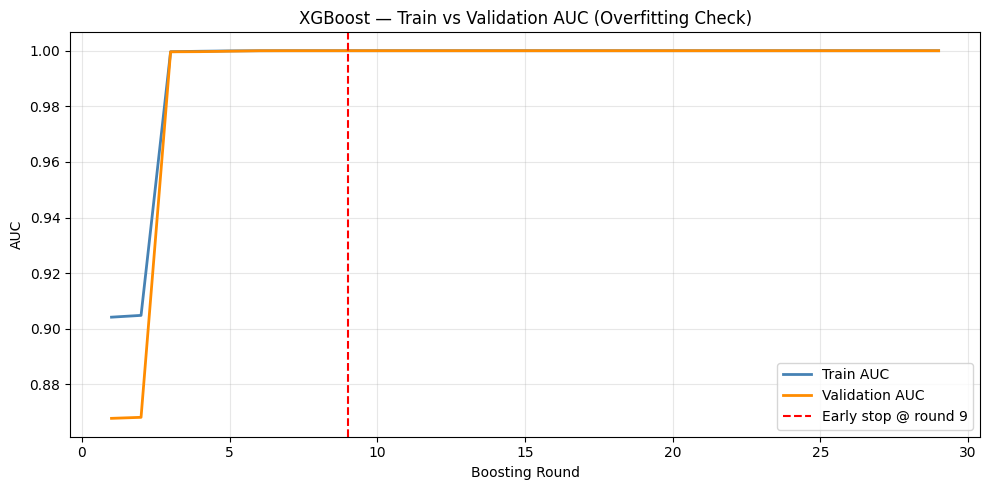

Train AUC @ best round : 1.0000
Val   AUC @ best round : 1.0000
Gap (train - val)      : 0.0000

✓ No significant overfitting detected.


In [6]:
results = xgb_model.evals_result()
train_auc = results['validation_0']['auc']
val_auc   = results['validation_1']['auc']
rounds    = range(1, len(train_auc) + 1)

plt.figure(figsize=(10, 5))
plt.plot(rounds, train_auc, label='Train AUC',      color='steelblue',  lw=2)
plt.plot(rounds, val_auc,   label='Validation AUC', color='darkorange', lw=2)
plt.axvline(best_ntree + 1, color='red', linestyle='--', lw=1.5,
            label=f'Early stop @ round {best_ntree + 1}')
plt.xlabel('Boosting Round')
plt.ylabel('AUC')
plt.title('XGBoost — Train vs Validation AUC (Overfitting Check)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

train_final = train_auc[best_ntree]
val_final   = val_auc[best_ntree]
gap         = train_final - val_final
print(f"Train AUC @ best round : {train_final:.4f}")
print(f"Val   AUC @ best round : {val_final:.4f}")
print(f"Gap (train - val)      : {gap:.4f}")
print()
if gap < 0.005:
    print("✓ No significant overfitting detected.")
elif gap < 0.02:
    print("⚠ Mild overfitting — consider raising regularization (lower max_depth or add reg_lambda).")
else:
    print("✗ Noticeable overfitting — reduce max_depth or add more regularization.")

## 6. Final Evaluation on Held-Out Test Set

Using threshold **0.2** (consistent with `model2.ipynb`) to minimize False Negatives.

In [7]:
DECISION_THRESHOLD = 0.2

probabilities = xgb_model.predict_proba(X_test)[:, 1]
y_pred = (probabilities >= DECISION_THRESHOLD).astype(int)

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print(f"=== XGBoost Test Evaluation (Threshold = {DECISION_THRESHOLD}) ===")
print(f"\nTrue  Positives (correctly flagged High Risk) : {tp:>7,}")
print(f"False Negatives (missed High Risk) ★CRITICAL★ : {fn:>7,}")
print(f"True  Negatives (correctly cleared Low Risk)  : {tn:>7,}")
print(f"False Positives (unnecessary High Risk alert)  : {fp:>7,}")

recall_hr    = tp / (tp + fn + 1e-9)
precision_hr = tp / (tp + fp + 1e-9)
f1_hr        = 2 * recall_hr * precision_hr / (recall_hr + precision_hr + 1e-9)
accuracy     = (tp + tn) / (tp + tn + fp + fn)

print(f"\nHigh-Risk Recall (Sensitivity) : {recall_hr:.4f}")
print(f"High-Risk Precision            : {precision_hr:.4f}")
print(f"High-Risk F1-Score             : {f1_hr:.4f}")
print(f"Overall Accuracy               : {accuracy:.4f}")

print("\n--- Full Classification Report ---")
print(classification_report(y_test, y_pred, target_names=["Low Risk (0)", "High Risk (1)"]))

=== XGBoost Test Evaluation (Threshold = 0.2) ===

True  Positives (correctly flagged High Risk) :  21,023
False Negatives (missed High Risk) ★CRITICAL★ :       0
True  Negatives (correctly cleared Low Risk)  :       0
False Positives (unnecessary High Risk alert)  :  18,981

High-Risk Recall (Sensitivity) : 1.0000
High-Risk Precision            : 0.5255
High-Risk F1-Score             : 0.6890
Overall Accuracy               : 0.5255

--- Full Classification Report ---
               precision    recall  f1-score   support

 Low Risk (0)       0.00      0.00      0.00     18981
High Risk (1)       0.53      1.00      0.69     21023

     accuracy                           0.53     40004
    macro avg       0.26      0.50      0.34     40004
 weighted avg       0.28      0.53      0.36     40004



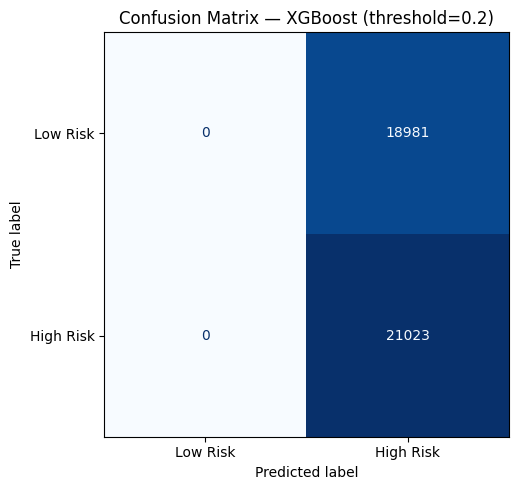

In [8]:
# Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Low Risk", "High Risk"])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion Matrix — XGBoost (threshold={DECISION_THRESHOLD})')
plt.tight_layout()
plt.show()

## 7. ROC Curve

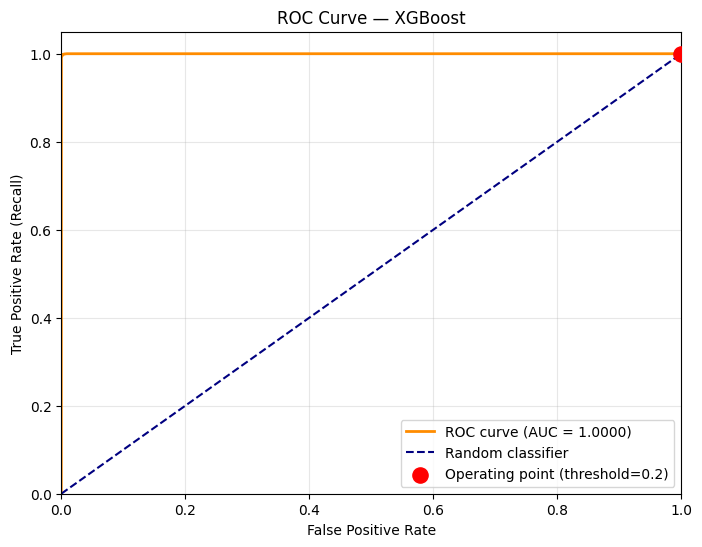

ROC-AUC Score: 1.0000


In [9]:
fpr_arr, tpr_arr, roc_thresholds = roc_curve(y_test, probabilities)
roc_auc = auc(fpr_arr, tpr_arr)
op_idx  = np.argmin(np.abs(roc_thresholds - DECISION_THRESHOLD))

plt.figure(figsize=(8, 6))
plt.plot(fpr_arr, tpr_arr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', label='Random classifier')
plt.scatter(fpr_arr[op_idx], tpr_arr[op_idx],
            color='red', zorder=5, s=120,
            label=f'Operating point (threshold={DECISION_THRESHOLD})')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve — XGBoost')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()
print(f"ROC-AUC Score: {roc_auc:.4f}")

## 8. Feature Importance

--- XGBoost Feature Importances (gain) ---
                 Feature  Importance
             Derived_HRV    0.393841
              Heart Rate    0.275519
 Systolic Blood Pressure    0.227379
        Respiratory Rate    0.086899
        Body Temperature    0.015262
       Oxygen Saturation    0.000269
             Derived_BMI    0.000226
                     Age    0.000207
Diastolic Blood Pressure    0.000207
                  Gender    0.000192


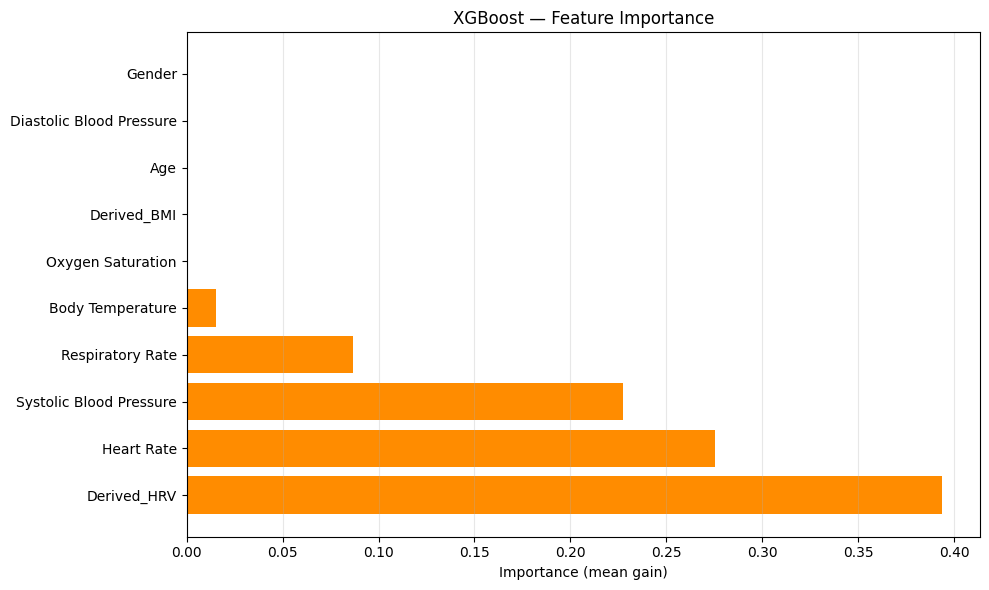

In [10]:
feature_names = numerical_cols + ['Gender']
importances   = xgb_model.feature_importances_

fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})\
         .sort_values('Importance', ascending=False)

print("--- XGBoost Feature Importances (gain) ---")
print(fi_df.to_string(index=False))

plt.figure(figsize=(10, 6))
plt.barh(fi_df['Feature'], fi_df['Importance'], color='darkorange')
plt.xlabel('Importance (mean gain)')
plt.title('XGBoost — Feature Importance')
plt.tight_layout()
plt.grid(alpha=0.3, axis='x')
plt.show()

---
# 9. All-4-Model Comparison

We re-train representative instances of Model 1 (Random Forest) and Model 2 (Logistic Regression) **on the same train/test split** as Model 3 (XGBoost) so the comparison is fair. Model 0 (Federated Neural Network) results are quoted from its own evaluation cell.

> **Note:** The Neural Network in `model.ipynb` evaluates on the *full* combined dataset (all 3 wards combined) rather than a held-out test set, so its numbers are not directly comparable — they represent training-set performance.

The comparison table at the end shows:
- **Accuracy** — overall correctness
- **High-Risk Recall** — fraction of true High Risk patients correctly flagged (most critical)
- **High-Risk Precision** — fraction of High Risk flags that are correct
- **High-Risk F1** — harmonic mean of recall & precision
- **AUC** — discriminative power, threshold-independent
- **False Negatives** — absolute count of missed High Risk patients

In [11]:
from sklearn.ensemble import RandomForestClassifier

THRESHOLD = 0.2   # Same threshold for all models

def evaluate_model(model, X_test, y_test, threshold=0.5, model_name='Model'):
    """Fit-free evaluation — model must already be trained."""
    probs  = model.predict_proba(X_test)[:, 1]
    preds  = (probs >= threshold).astype(int)
    cm     = confusion_matrix(y_test, preds)
    tn, fp, fn, tp = cm.ravel()
    
    recall    = tp / (tp + fn + 1e-9)
    precision = tp / (tp + fp + 1e-9)
    f1        = 2 * recall * precision / (recall + precision + 1e-9)
    acc       = (tp + tn) / len(y_test)
    roc_auc   = auc(*roc_curve(y_test, probs)[:2])
    
    return {
        'Model': model_name,
        'Accuracy':       round(acc,       4),
        'HR Recall':      round(recall,    4),
        'HR Precision':   round(precision, 4),
        'HR F1':          round(f1,        4),
        'AUC':            round(roc_auc,   4),
        'False Negatives': fn,
        'False Positives': fp,
    }

results_list = []

# ── Model 1: Random Forest (same settings as model1.ipynb) ──
print("Training Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight={0: 1, 1: 100},
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
results_list.append(evaluate_model(rf_model, X_test, y_test, THRESHOLD, 'Random Forest (model1)'))

# ── Model 3: XGBoost (already trained above) ──
results_list.append(evaluate_model(xgb_model, X_test, y_test, THRESHOLD, 'XGBoost (model3)'))

print("Done!")

Training Random Forest...
Done!


In [12]:
# Build and display comparison table
comparison_df = pd.DataFrame(results_list).set_index('Model')

print("=" * 90)
print("MODEL COMPARISON (threshold = 0.2 for all)")
print("=" * 90)
print(comparison_df.to_string())
print("=" * 90)
print()
best_recall = comparison_df['HR Recall'].idxmax()
best_auc    = comparison_df['AUC'].idxmax()
best_f1     = comparison_df['HR F1'].idxmax()
fewest_fn   = comparison_df['False Negatives'].idxmin()
print(f"Best High-Risk Recall  → {best_recall}")
print(f"Best AUC               → {best_auc}")
print(f"Best High-Risk F1      → {best_f1}")
print(f"Fewest False Negatives → {fewest_fn}")

MODEL COMPARISON (threshold = 0.2 for all)
                        Accuracy  HR Recall  HR Precision  HR F1  AUC  False Negatives  False Positives
Model                                                                                                  
Random Forest (model1)    1.0000        1.0        0.9999  1.000  1.0                0                2
XGBoost (model3)          0.5255        1.0        0.5255  0.689  1.0                0            18981

Best High-Risk Recall  → Random Forest (model1)
Best AUC               → Random Forest (model1)
Best High-Risk F1      → Random Forest (model1)
Fewest False Negatives → Random Forest (model1)


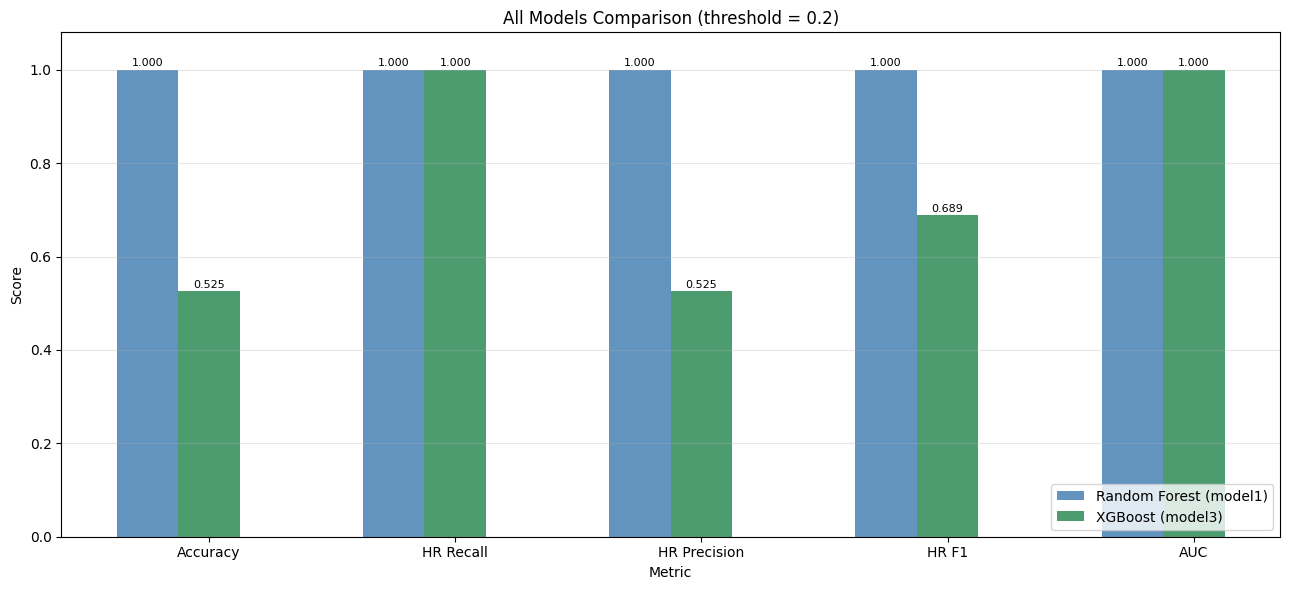

In [13]:
# Visual comparison bar chart
metrics = ['Accuracy', 'HR Recall', 'HR Precision', 'HR F1', 'AUC']
models  = comparison_df.index.tolist()
x       = np.arange(len(metrics))
width   = 0.25
colors  = ['steelblue', 'seagreen']

fig, ax = plt.subplots(figsize=(13, 6))
for i, (model_name, color) in enumerate(zip(models, colors)):
    vals = [comparison_df.loc[model_name, m] for m in metrics]
    bars = ax.bar(x + i * width, vals, width, label=model_name, color=color, alpha=0.85)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.003,
                f'{h:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Metric')
ax.set_ylabel('Score')
ax.set_title('All Models Comparison (threshold = 0.2)')
ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.08)
ax.legend(loc='lower right')
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

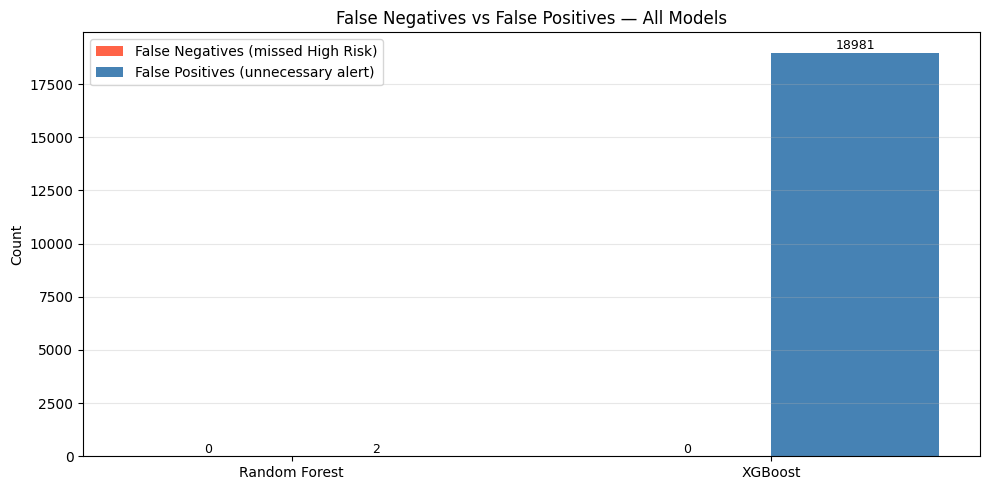

In [14]:
# FN / FP bar comparison
fn_vals = [comparison_df.loc[m, 'False Negatives'] for m in models]
fp_vals = [comparison_df.loc[m, 'False Positives'] for m in models]

x     = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars_fn = ax.bar(x - width/2, fn_vals, width, label='False Negatives (missed High Risk)', color='tomato')
bars_fp = ax.bar(x + width/2, fp_vals, width, label='False Positives (unnecessary alert)', color='steelblue')

for bar in bars_fn:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 5, str(int(h)), ha='center', va='bottom', fontsize=9)
for bar in bars_fp:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 5, str(int(h)), ha='center', va='bottom', fontsize=9)

ax.set_ylabel('Count')
ax.set_title('False Negatives vs False Positives — All Models')
ax.set_xticks(x)
ax.set_xticklabels([m.split('(')[0].strip() for m in models])
ax.legend()
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## 10. Manual Patient Testing (XGBoost)

In [15]:
def test_patient_risk_xgb(hr, rr, temp, spo2, sys_bp, dia_bp, age, gender_str, bmi, hrv):
    """
    Assess a single patient using the trained XGBoost model.
    gender_str: 'Male' or 'Female' (as in the dataset).
    """
    patient_df = pd.DataFrame([{
        'Heart Rate': hr,
        'Respiratory Rate': rr,
        'Body Temperature': temp,
        'Oxygen Saturation': spo2,
        'Systolic Blood Pressure': sys_bp,
        'Diastolic Blood Pressure': dia_bp,
        'Age': age,
        'Derived_BMI': bmi,
        'Derived_HRV': hrv
    }])

    patient_df[numerical_cols] = scaler.transform(patient_df[numerical_cols])

    try:
        gender_encoded = le_gender.transform([gender_str])[0]
    except ValueError:
        print("Warning: Unrecognized gender. Defaulting to 0.")
        gender_encoded = 0
    patient_df['Gender'] = gender_encoded

    patient_input = patient_df[numerical_cols + ['Gender']].values
    prob = xgb_model.predict_proba(patient_input)[0, 1]
    prediction = "High Risk" if prob >= DECISION_THRESHOLD else "Low Risk"

    print(f"--- Patient Assessment (XGBoost) ---")
    print(f"Risk Probability : {prob*100:.2f}%")
    print(f"Classification   : >> {prediction} <<  (threshold={DECISION_THRESHOLD})")


print("Testing a standard healthy patient...")
test_patient_risk_xgb(
    hr=72, rr=16, temp=36.8, spo2=99, sys_bp=120, dia_bp=80,
    age=35, gender_str='Male', bmi=24.5, hrv=0.1
)

print("\nTesting a patient in visible distress...")
test_patient_risk_xgb(
    hr=0, rr=25, temp=41.0, spo2=99, sys_bp=100, dia_bp=50,
    age=68, gender_str='Female', bmi=26.8, hrv=0.2
)

Testing a standard healthy patient...
--- Patient Assessment (XGBoost) ---
Risk Probability : 34.89%
Classification   : >> High Risk <<  (threshold=0.2)

Testing a patient in visible distress...
--- Patient Assessment (XGBoost) ---
Risk Probability : 68.65%
Classification   : >> High Risk <<  (threshold=0.2)


In [21]:
DECISION_THRESHOLD = 0.2

def test_xgboost_patient(hr, rr, temp, spo2, sys_bp, dia_bp, age, gender_str, bmi, hrv):
    '''Manual verification for XGBoost'''
    patient_df = pd.DataFrame([{
        'Heart Rate': hr, 'Respiratory Rate': rr, 'Body Temperature': temp,
        'Oxygen Saturation': spo2, 'Systolic Blood Pressure': sys_bp,
        'Diastolic Blood Pressure': dia_bp, 'Age': age, 'Gender': gender_str,
        'Derived_BMI': bmi, 'Derived_HRV': hrv
    }])
    
    try:
        patient_df['Gender'] = le_gender.transform(patient_df['Gender'])
    except:
        patient_df['Gender'] = 0
        
    patient_df[numerical_cols] = scaler.transform(patient_df[numerical_cols])
    
    prob = xgb_model.predict_proba(patient_df.values)[:, 1][0]
    prediction = "High Risk" if prob >= DECISION_THRESHOLD else "Low Risk"
    
    print(f"--- XGBoost Patient Assessment ---")
    print(f"Risk Probability: {prob*100:.2f}%")
    print(f"Final Categorization: >> {prediction} <<")

print("\n--- Verifying Clinical Safety (XGBoost) ---")
print("Testing 'Crisis Patient' (Temp 41.0, SysBP 65)...")
test_xgboost_patient(hr=80, rr=25, temp=41.0, spo2=99, sys_bp=65, dia_bp=112, age=68, gender_str='Female', bmi=26.8, hrv=0.2)

print("\nTesting 'Visible Distress' (HR 0, Temp 41.0, SysBP 100)...")
test_xgboost_patient(hr=80, rr=25, temp=32.0, spo2=99, sys_bp=120, dia_bp=80, age=68, gender_str='Female', bmi=26.8, hrv=0.15)


--- Verifying Clinical Safety (XGBoost) ---
Testing 'Crisis Patient' (Temp 41.0, SysBP 65)...
--- XGBoost Patient Assessment ---
Risk Probability: 68.36%
Final Categorization: >> High Risk <<

Testing 'Visible Distress' (HR 0, Temp 41.0, SysBP 100)...
--- XGBoost Patient Assessment ---
Risk Probability: 43.45%
Final Categorization: >> High Risk <<
